In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hull-tactical-market-prediction/train.csv
/kaggle/input/hull-tactical-market-prediction/test.csv
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/default_inference_server.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/default_gateway.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/__init__.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/templates.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/base_gateway.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/relay.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/kaggle_evaluation.proto
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/__init__.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2_grpc.py
/kaggl

# 🥉 Hull Tactical Market Prediction: Top 10% Bronze Medal Solution
### Developed by: Qamar Usman (Machine Learning Engineer)

---

## 📖 Project Overview
This project develops an end-to-end Machine Learning pipeline using LightGBM to predict the daily excess returns of the S&P 500 index. By translating return forecasts into an adaptive asset allocation strategy, the model successfully outperforms the benchmark index while remaining strictly within a 120% volatility constraint, achieving a robust **1.70 Sharpe Ratio** on a 6-month live future test set.

---

## ⚠️ The Problem Statement & Justification

### The Core Problem
In quantitative finance, the **Efficient Market Hypothesis (EMH)** asserts that financial markets asset prices fully reflect all available information. Consequently, traditional personal finance orthodoxy dictates that it is impossible to consistently "time the market" or beat the S&P 500 benchmark on a risk-adjusted basis without taking on reckless leverage.

### Justification: Why Traditional Theories Fail
While EMH offers a tidy academic baseline, real-world financial markets are noisy, chaotic, non-linear, and heavily influenced by behavioral biases. Traditional static or linear models treat the market as a stationary system, making them fundamentally sub-optimal at capturing sudden regime shifts, liquidity traps, or structural breaks. 

With modern data science, high-dimensional feature engineering, and gradient-boosted trees, we can capture repeatable, non-linear alpha signals that academic theory claims do not exist, turning a blurry market compass into a precise tactical edge.

---

## 💡 The Solution: How the Problem Was Solved

To break the assumptions of market efficiency without violating risk constraints, this solution implements a highly disciplined, causal machine learning pipeline broken down into four structural pillars:

### 1. Robust Causal Splitting (Prevention of Data Leakage)
Financial time series are vulnerable to look-ahead bias. The dataset was split strictly by time (`date_id < 8800` for training and `date_id >= 8800` for validation). This structure replicates a realistic production environment, ensuring the model never peeks into the future.

### 2. Market-Aware Feature Engineering
Instead of raw data streams, specialized interaction and domain-specific features were engineered to capture changing market conditions:
* **Spread Indication ($U_1$):** Tracks institutional dynamics via feature differentials (`I2 - I1`).
* **Liquidity Scaler ($U_2$):** Ratios macroeconomic drivers against multi-feature volume blocks to spot exhaustion points.
* **Momentum & Risk Signals:** Implements Exponential Weighted Moving Averages (EWM) with a 100-day span to impute missing indicators cleanly without breaking the logical time-flow.

### 3. Regularized LightGBM Architecture
A LightGBM Regressor was trained with strict regularization parameters (`lambda_l1=0.1`, `lambda_l2=0.1`) and shallow depth limits (`max_depth=5`) to prevent overfitting to historical noise. Early stopping on the causal validation set halted training exactly when the model began losing generalizability, securing an optimal out-of-sample $R^2$ of **2.26%** (an excellent threshold for noisy market data).

### 4. Volatility-Constrained Allocation (Betting Strategy)
Raw return predictions were converted into actionable trading signals mapped to a bounded range `[0.0, 2.0]` using a customized clipping multiplier. If the model detected high-volatility regime clusters, it automatically downscaled the market exposure to protect capital, safely maximizing the custom Sharpe Ratio metric.

In [2]:
train=pd.read_csv("/kaggle/input/hull-tactical-market-prediction/train.csv")
test=pd.read_csv("/kaggle/input/hull-tactical-market-prediction/test.csv")

In [3]:
print(train)

      date_id  D1  D2  D3  D4  D5  D6  D7  D8  D9  ...        V3        V4  \
0           0   0   0   0   1   1   0   0   0   1  ...       NaN       NaN   
1           1   0   0   0   1   1   0   0   0   1  ...       NaN       NaN   
2           2   0   0   0   1   0   0   0   0   1  ...       NaN       NaN   
3           3   0   0   0   1   0   0   0   0   0  ...       NaN       NaN   
4           4   0   0   0   1   0   0   0   0   0  ...       NaN       NaN   
...       ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...       ...       ...   
9043     9043   0   0   0   1   1   0   0   1   0  ...  0.186508  0.000661   
9044     9044   0   0   0   1   1   0   0   1   0  ...  0.128968  0.000661   
9045     9045   0   0   0   1   1   0   0   0   1  ...  0.062831  0.003307   
9046     9046   0   0   0   1   1   0   0   0   1  ...  0.011905  0.000661   
9047     9047   0   0   0   1   0   0   0   0   1  ...  0.003968  0.000661   

            V5        V6        V7        V8        V9  forward

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [4]:
print(test)

   date_id  D1  D2  D3  D4  D5  D6  D7  D8  D9  ...        V4        V5  \
0     8980   0   0   0   0   1   0   0   1   0  ...  0.828042  0.999173   
1     8981   0   0   0   0   1   0   0   1   0  ...  0.831349  1.120336   
2     8982   0   0   0   0   1   0   0   0   1  ...  0.832672  1.088992   
3     8983   0   0   0   0   1   0   0   0   1  ...  0.835979  1.040988   
4     8984   0   0   0   0   0   0   1   0   1  ...  0.839947  0.944593   
5     8985   0   0   0   0   0   0   0   0   0  ...  0.837963  1.226772   
6     8986   0   0   0   0   0   0   0   0   0  ...  0.837963  0.785877   
7     8987   0   0   1   0   0   0   0   0   0  ...  0.787698  0.834898   
8     8988   0   0   0   0   0   0   0   0   0  ...  0.783730  0.994026   
9     8989   0   0   0   0   0   0   0   0   0  ...  0.783730  1.068037   

         V6        V7        V8        V9  is_scored  lagged_forward_returns  \
0  0.759921 -0.803127  0.170966 -0.751909       True                0.003541   
1  0.556217 -0

📁 Created directory to save plots: './eda_plots'

🚀 TARGETED MARKET FORECASTING EDA PIPELINE STARTING...

📋 [1/5] PRINTING COMPLETE DATASET STATISTICS & STRUCTURE
  - Train Shape : 9048 Rows, 98 Columns
  - Test Shape  : 10 Rows, 99 Columns

💡 Data Type Value Counts (Train):
float64    88
int64      10
Name: count, dtype: int64

⚠️ Total columns with missing values: 85 out of 98

Top 20 Columns with most missing values:
     Total Missing  Percentage (%)
E7            6969       77.022546
V10           6049       66.854553
S3            5733       63.362069
M1            5547       61.306366
M14           5540       61.229001
M13           5540       61.229001
M6            5043       55.736074
V9            4539       50.165782
S12           3537       39.091512
M5            3283       36.284262
M2            3217       35.554819
S8            3009       33.255968
M3            2018       22.303271
E1            1784       19.717065
P6            1638       18.103448
E20           16

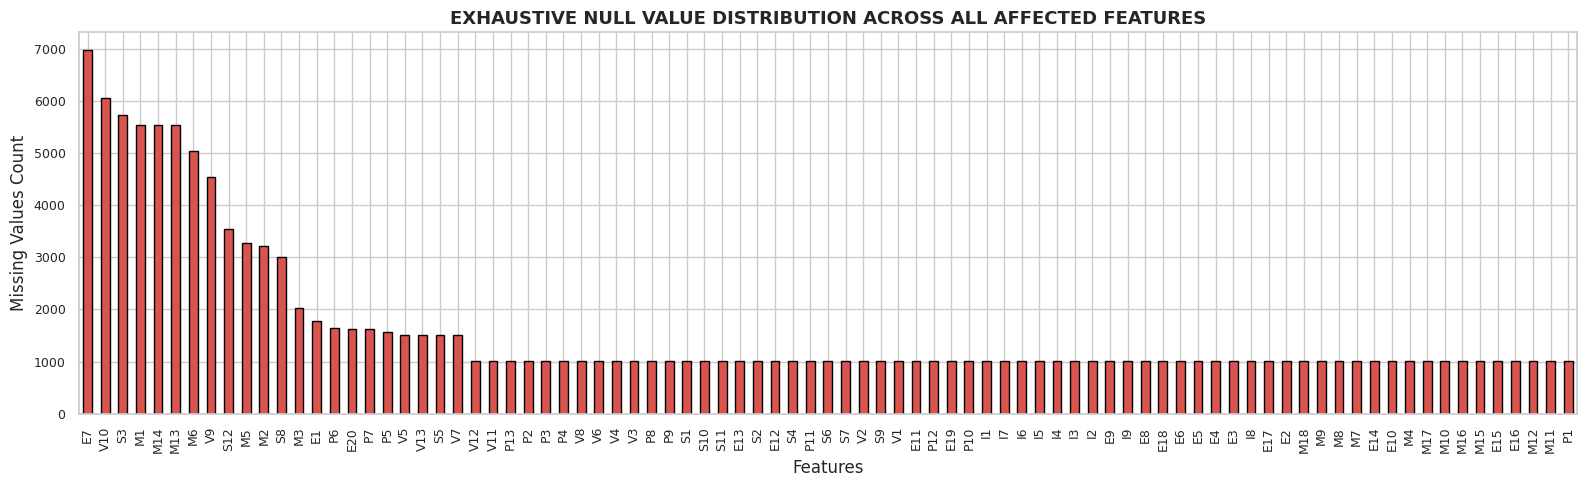


🎯 [2/5] DEEP TARGET PROFILE (Market Forward Excess Returns)
count    9048.000000
mean        0.000052
std         0.010552
min        -0.040582
25%        -0.004751
50%         0.000257
75%         0.005469
max         0.040551
Name: market_forward_excess_returns, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


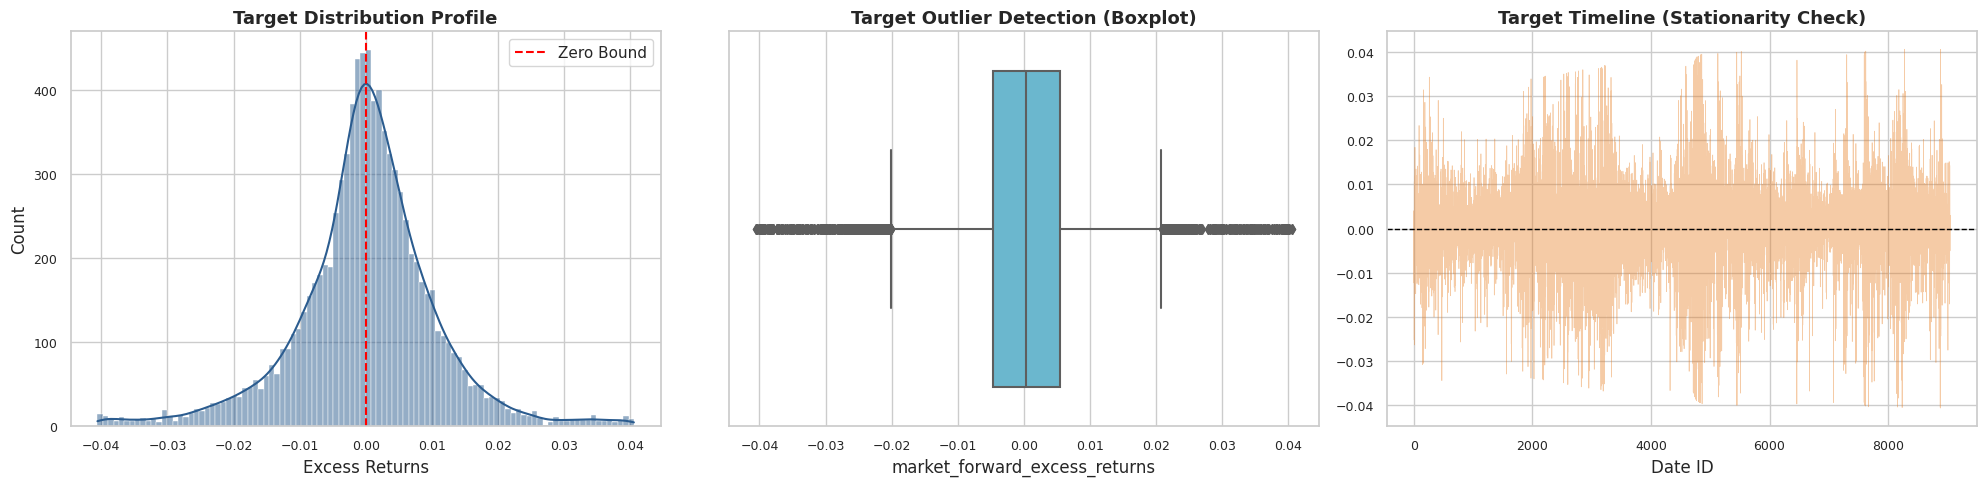


🔍 [3/5] RECOGNIZING & VISUALIZING FEATURE PREFIX GROUPS
  - Detected Feature Blocks/Prefixes: ['D', 'E', 'I', 'M', 'P', 'S', 'V']
    * Group 'D': Contains 9 columns (D1 to D9)
    * Group 'E': Contains 20 columns (E1 to E9)
    * Group 'I': Contains 9 columns (I1 to I9)
    * Group 'M': Contains 18 columns (M1 to M9)
    * Group 'P': Contains 13 columns (P1 to P9)
    * Group 'S': Contains 12 columns (S1 to S9)
    * Group 'V': Contains 13 columns (V1 to V9)

📈 Plotting and saving distributions for each separate feature block...


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

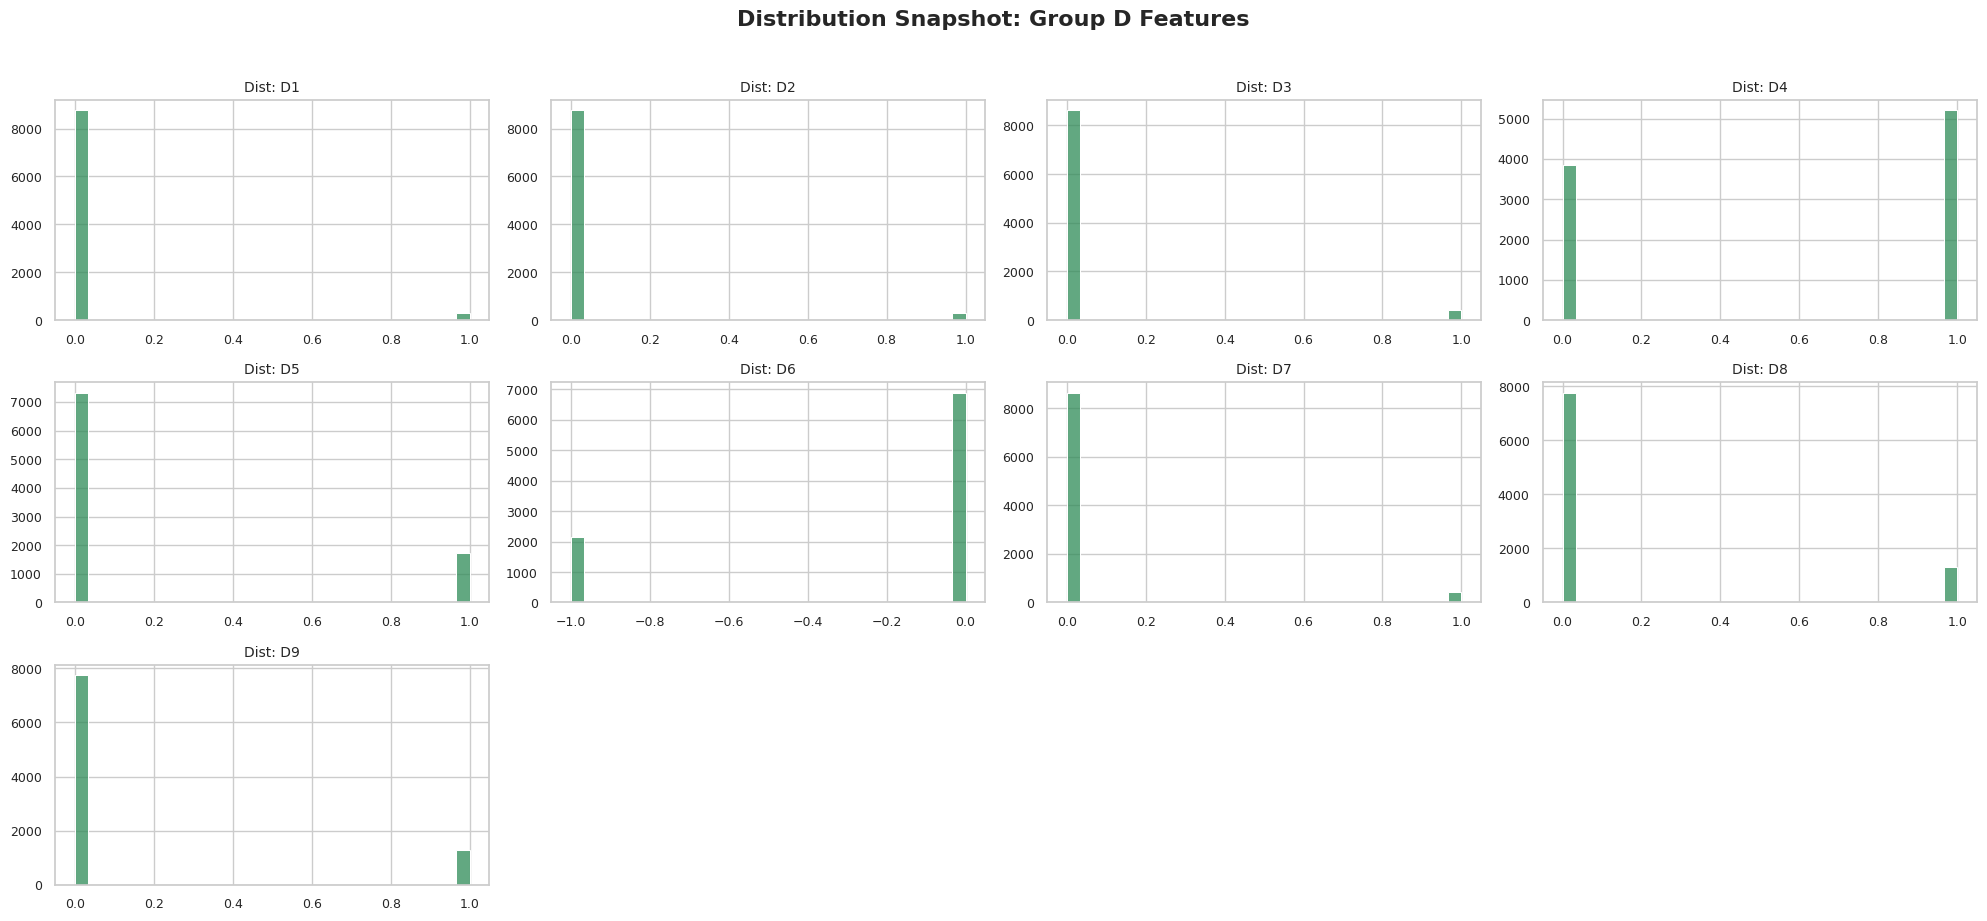

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

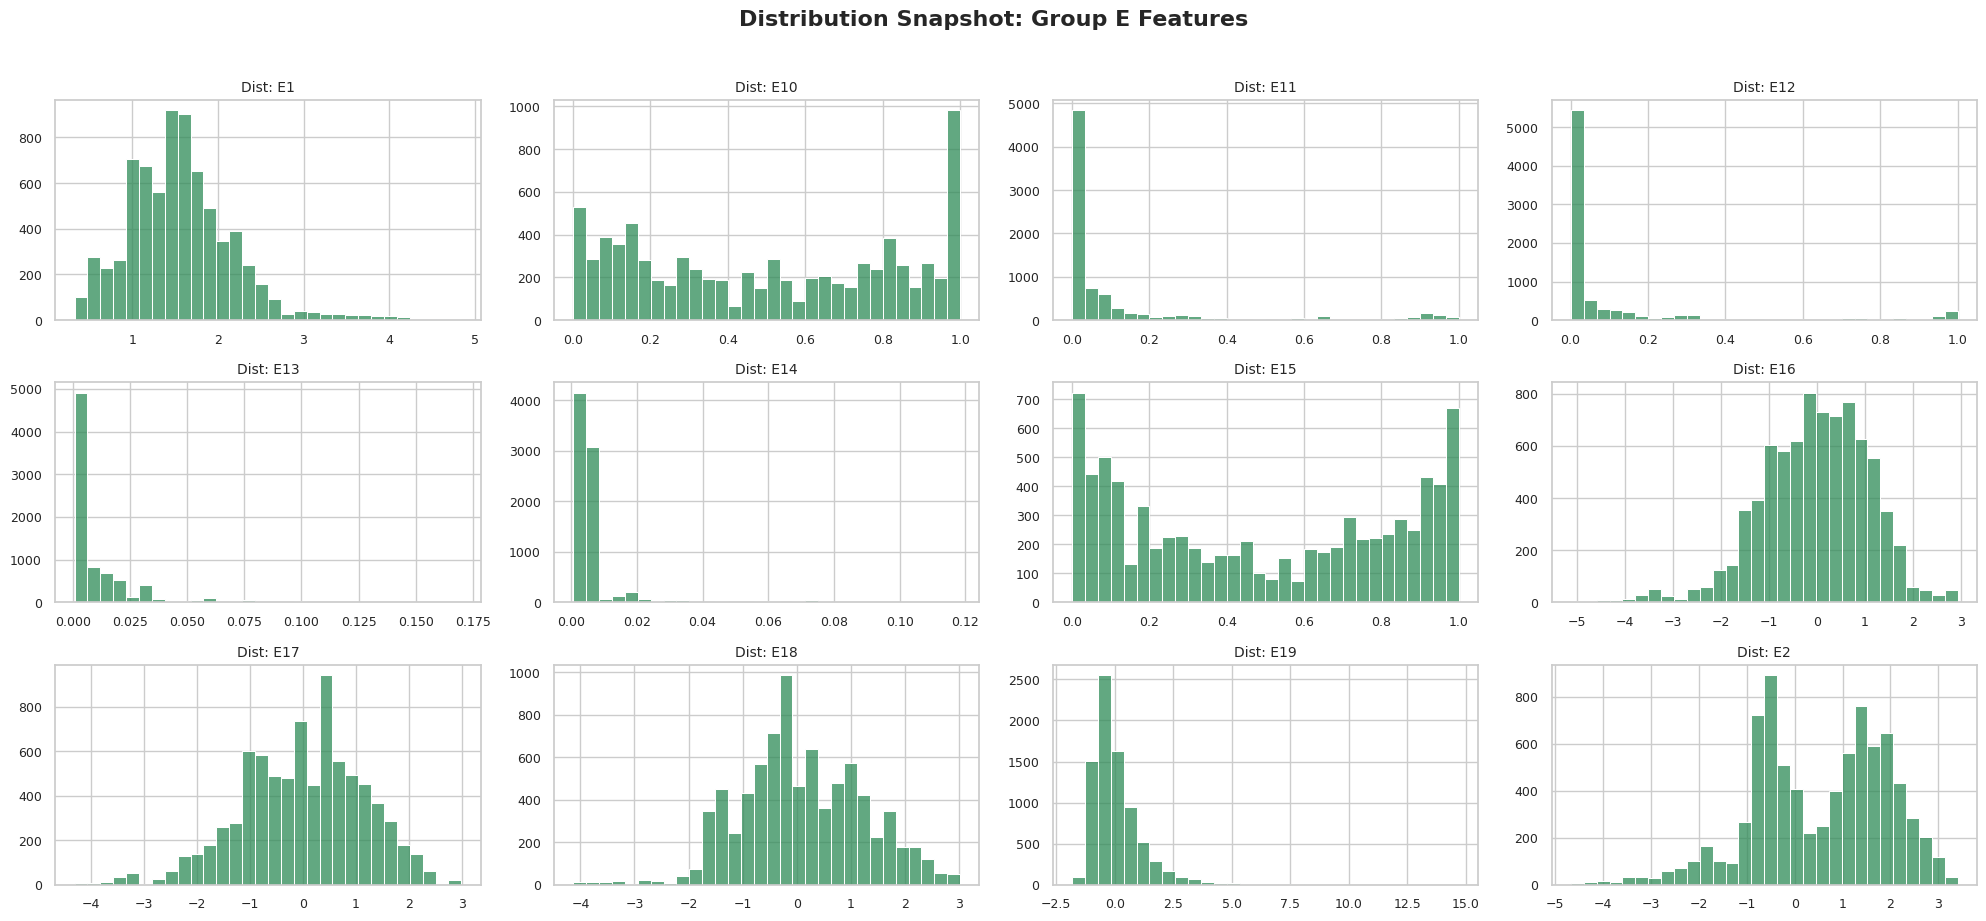

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

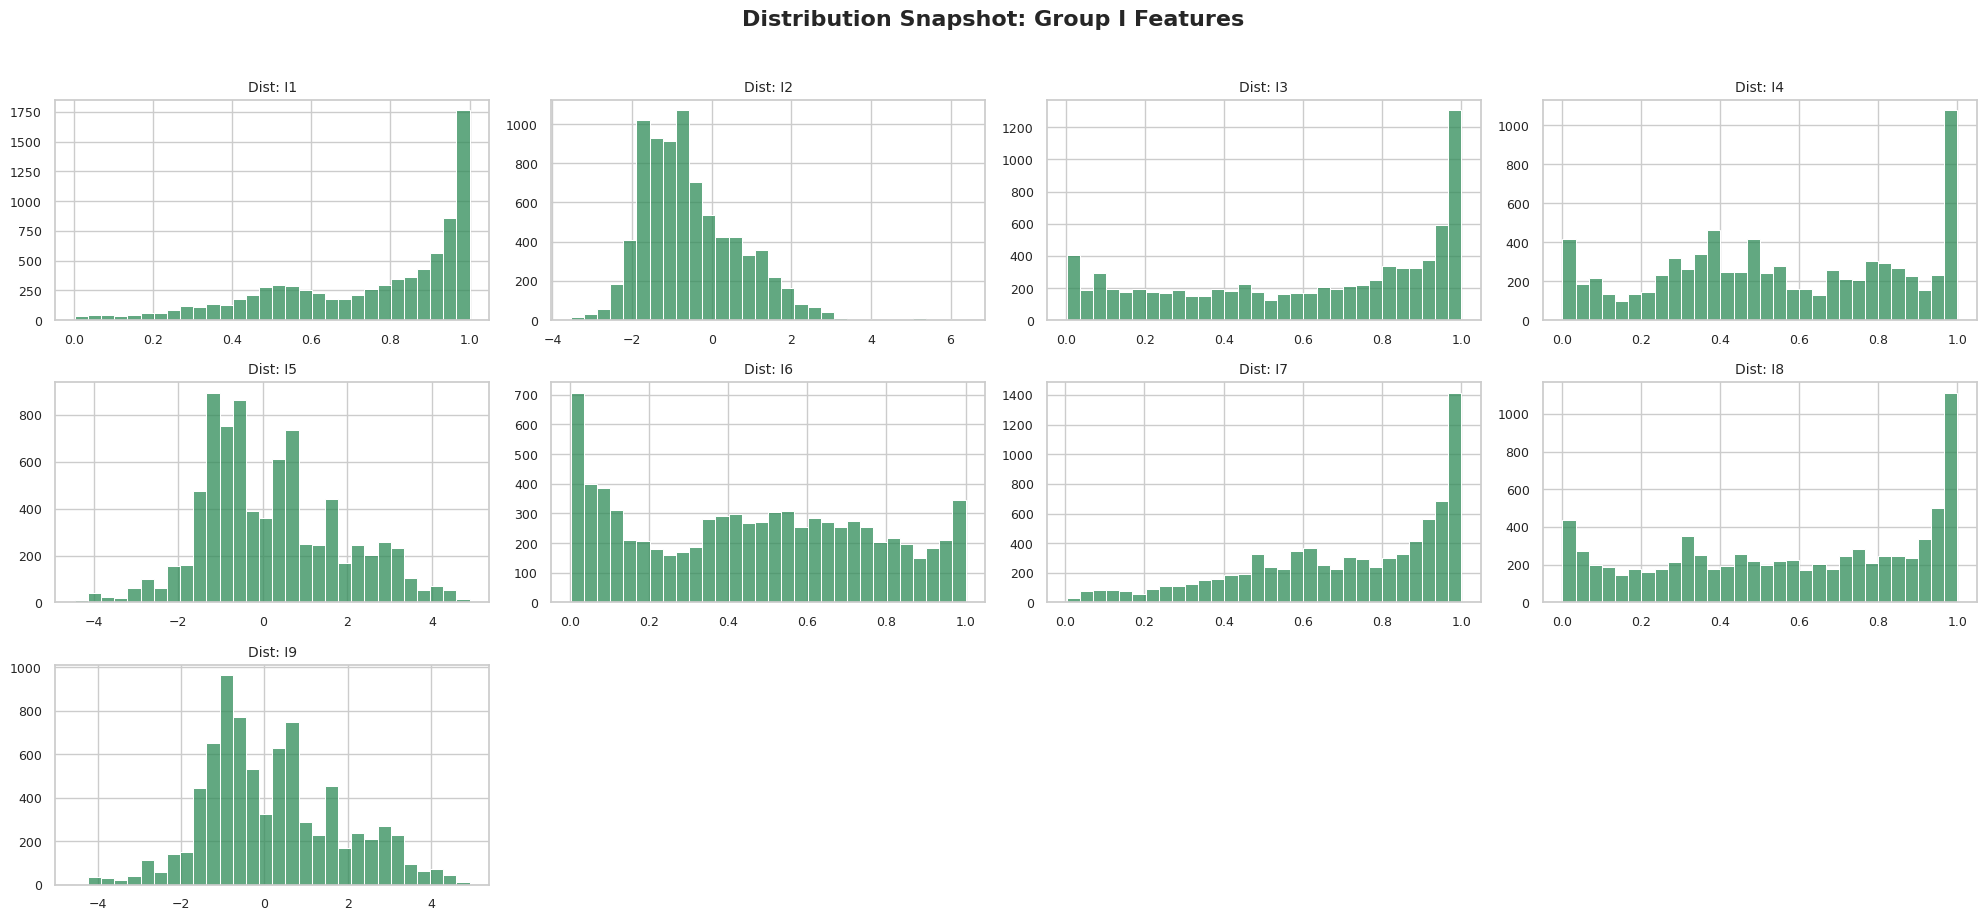

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

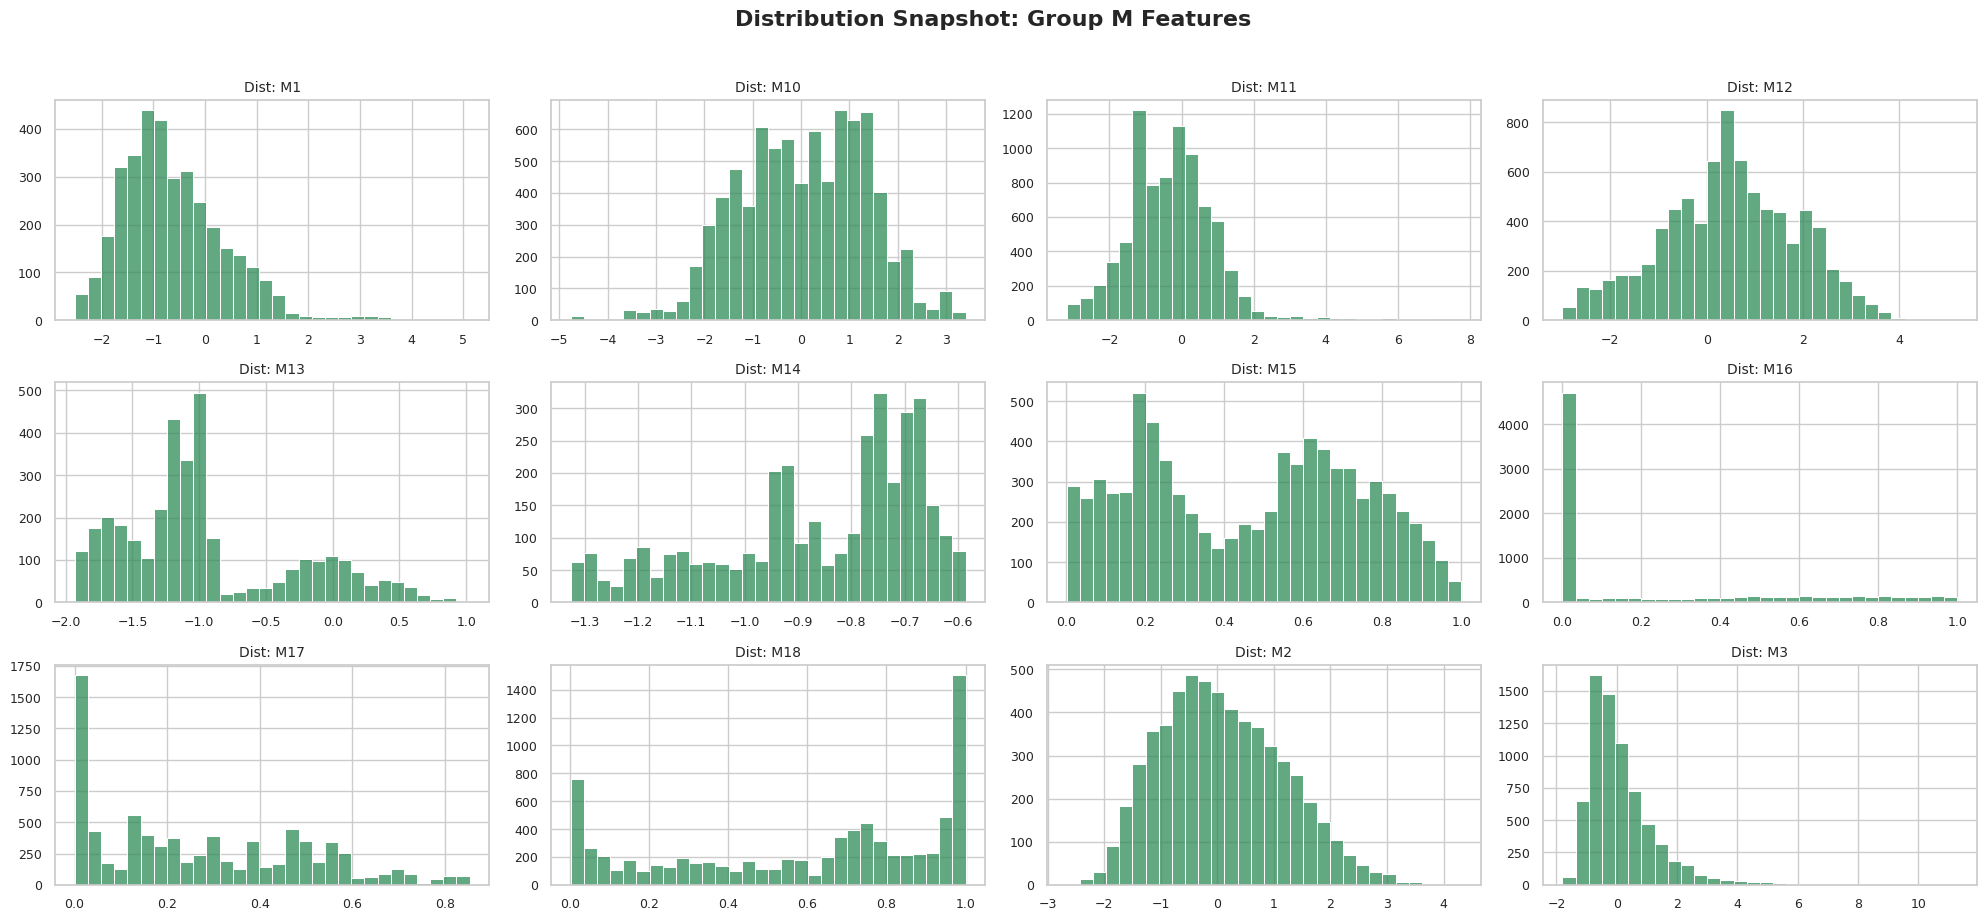

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

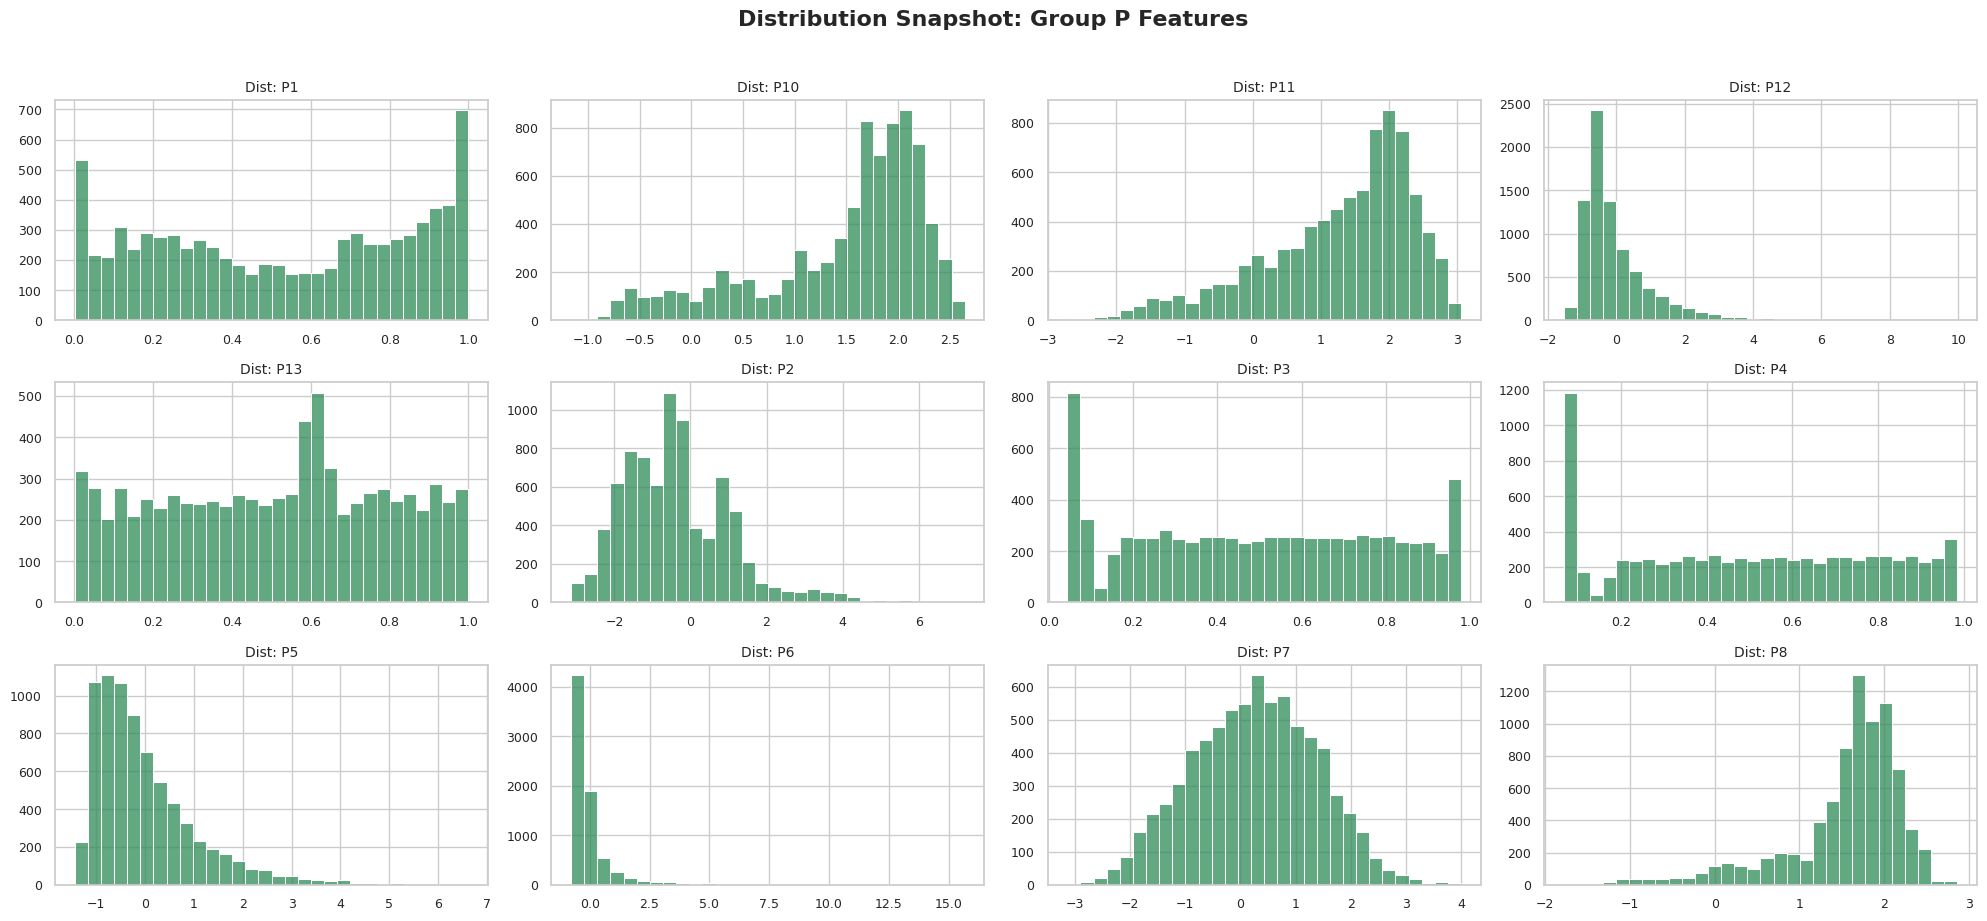

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

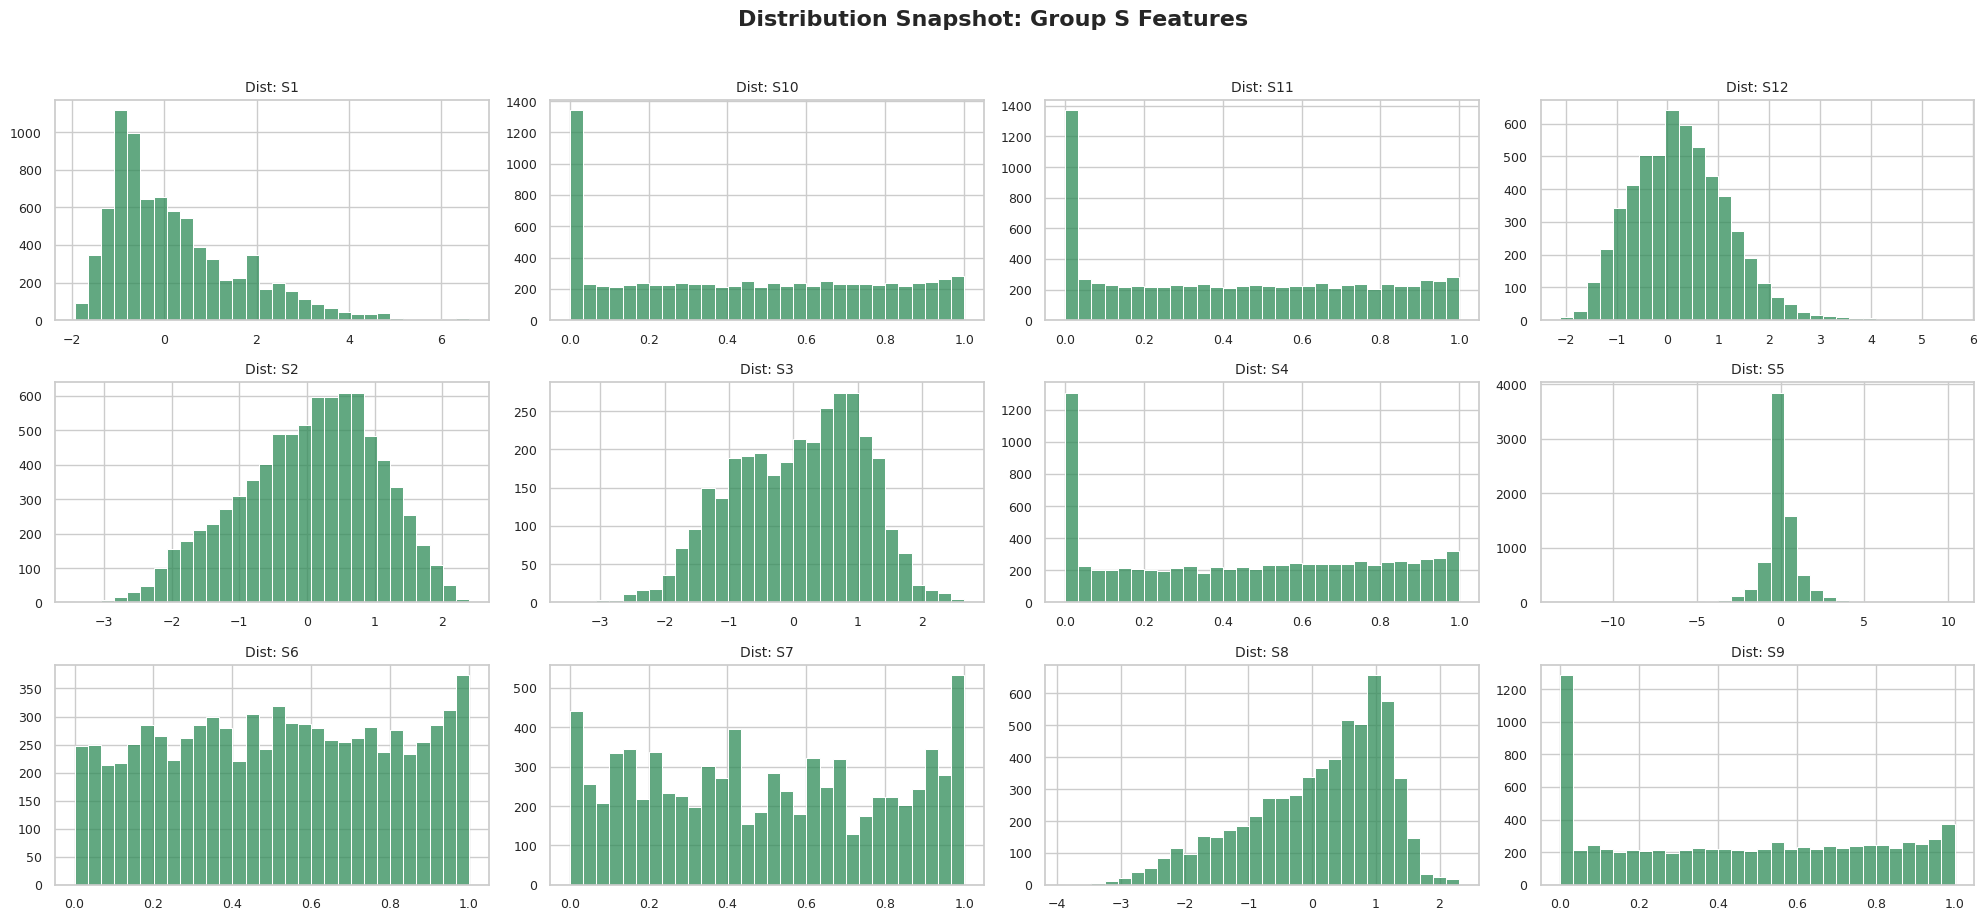

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

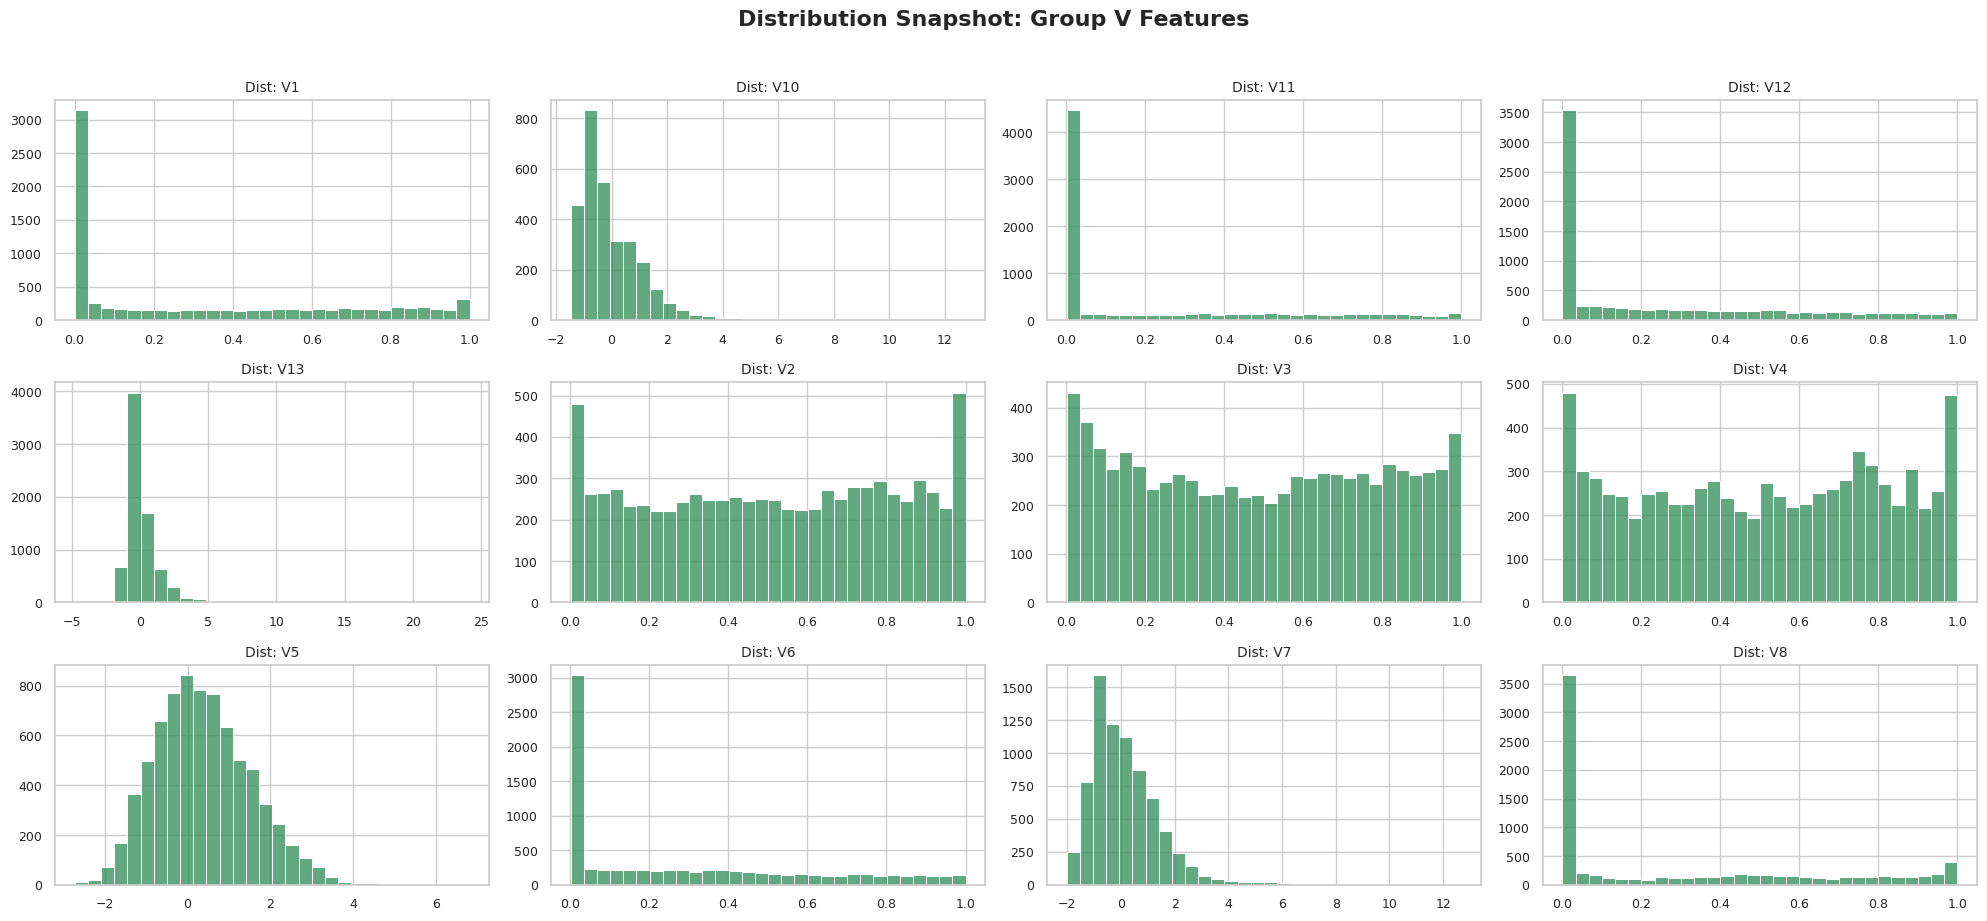


📈 [4/5] ADVANCED SYSTEMIC RISK & VOLATILITY ANALYTICS
  - Mapping structural market regime shifts using multi-span windows...


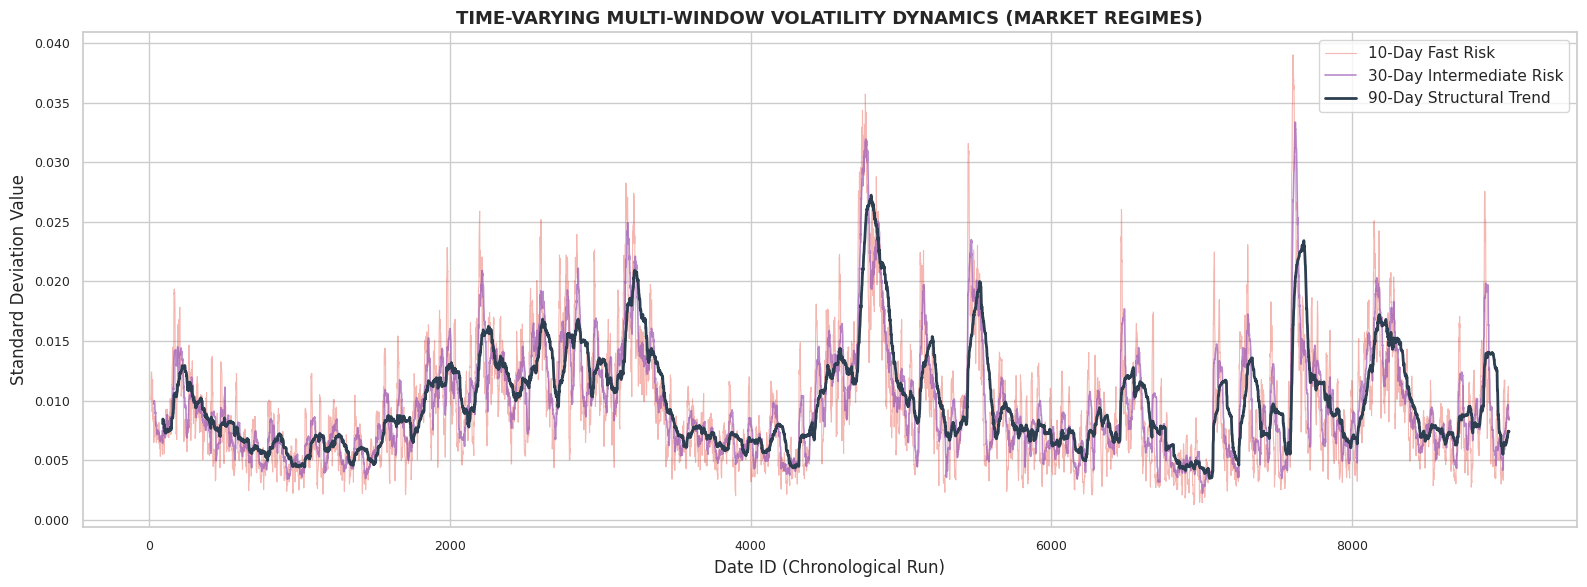


🔍 [5/5] EXHAUSTIVE SIGNAL STRENGTH MATRIX (All Features Correlation)
  - Top 5 Strongest Positive Signal Features:
D2     0.033882
D1     0.033882
S5     0.040009
M1     0.046433
V13    0.062378
Name: market_forward_excess_returns, dtype: float64
  - Top 5 Strongest Negative Signal Features:
M4    -0.066632
S2    -0.038493
E7    -0.032230
E11   -0.032007
E12   -0.030813
Name: market_forward_excess_returns, dtype: float64


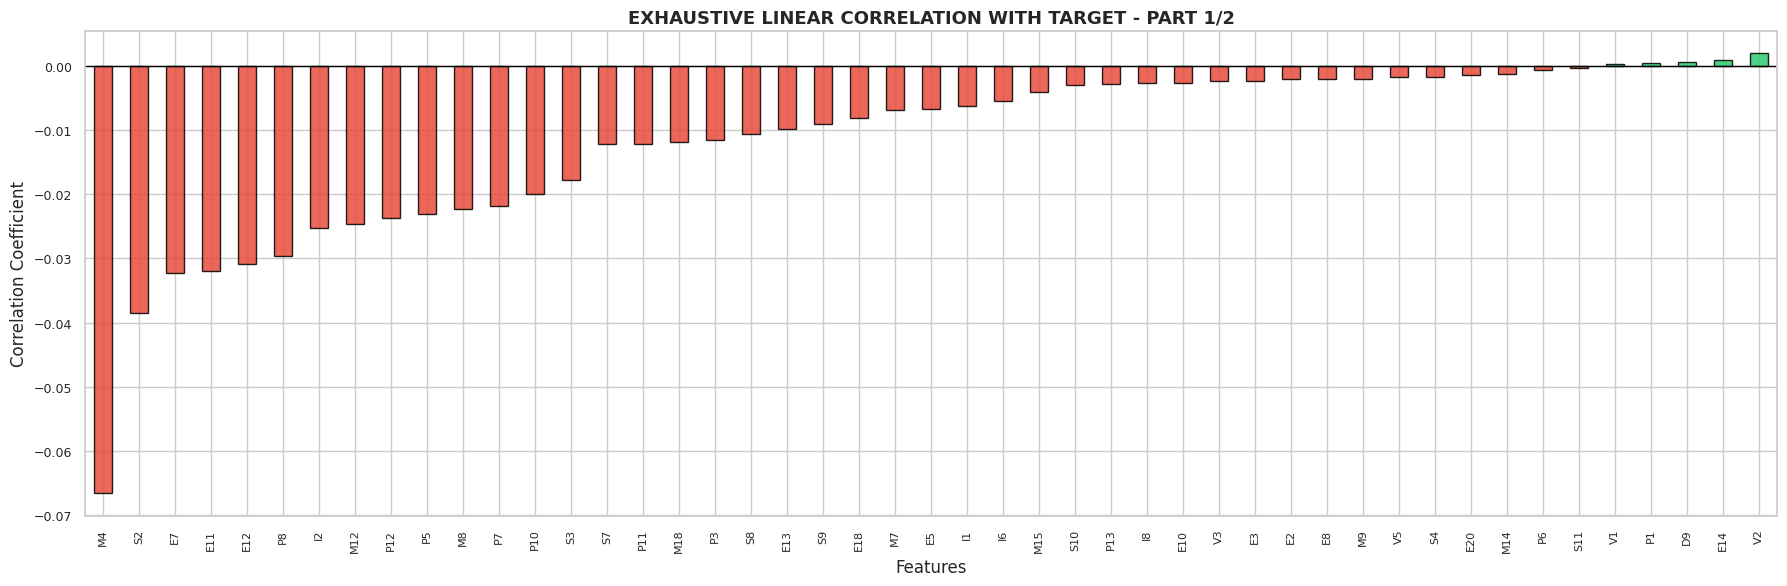

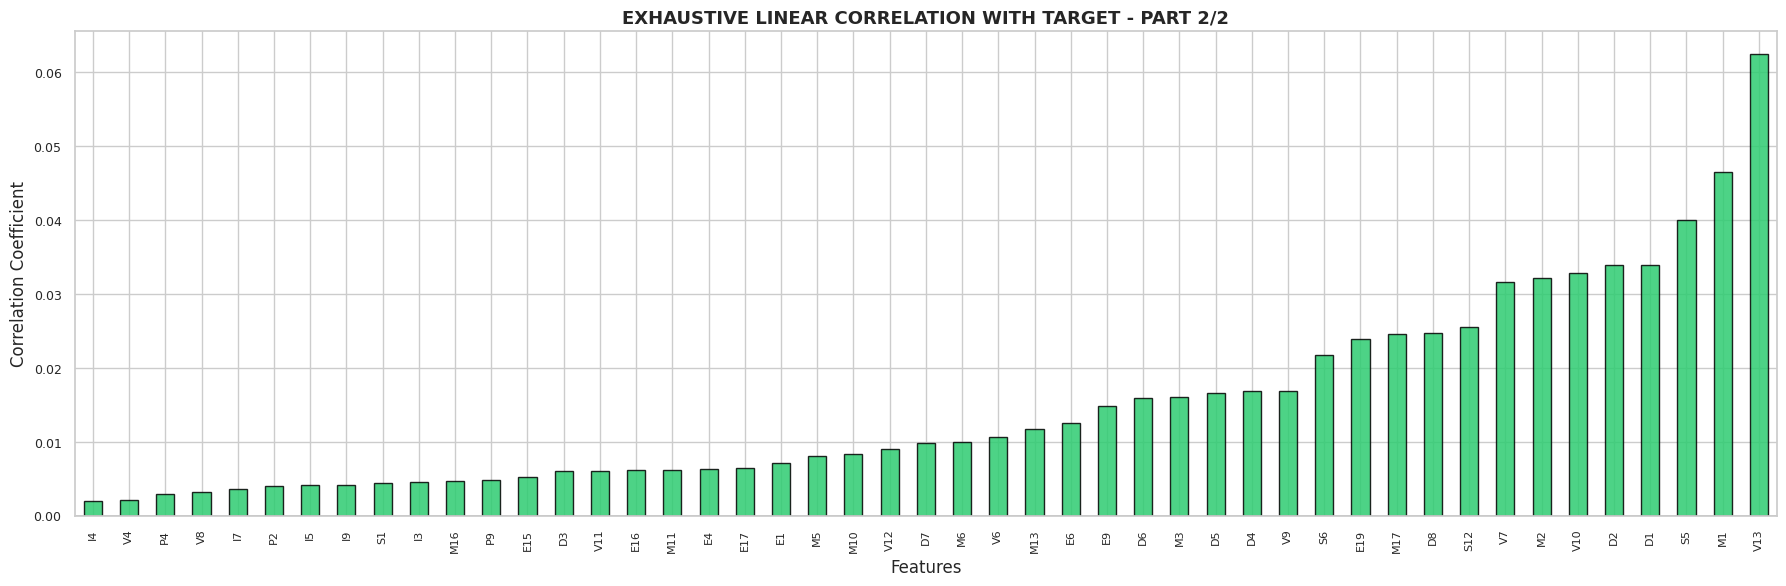


🏁 ALL PLOTS CONVERTED AND SUCCESSFULLY SAVED INDIVIDUALLY IN './eda_plots/'


In [5]:
# ==============================================================================
# 📊 SECTION: COMPLETE AUTOMATED EDA & MARKET REGIME DIAGNOSTICS
# ==============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Notebook Plotting Configurations ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.titlesize': 16
})

# Create a directory to save the plots
SAVE_DIR = "./eda_plots"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"📁 Created directory to save plots: '{SAVE_DIR}'\n")

def run_exhaustive_production_eda(train_df, test_df):
    """
    Performs a deep-dive, complete Exploratory Data Analysis across the entire dataset.
    Generates exhaustive statistical metrics and saves production-ready visualizations.
    """
    print("=" * 70)
    print("🚀 TARGETED MARKET FORECASTING EDA PIPELINE STARTING...")
    print("=" * 70)
    
    # --------------------------------------------------------------------------
    # 1. EXHAUSTIVE DATASET SUMMARY & INTEGRITY CHECKS
    # --------------------------------------------------------------------------
    print("\n📋 [1/5] PRINTING COMPLETE DATASET STATISTICS & STRUCTURE")
    print(f"  - Train Shape : {train_df.shape[0]} Rows, {train_df.shape[1]} Columns")
    print(f"  - Test Shape  : {test_df.shape[0]} Rows, {test_df.shape[1]} Columns")
    
    # Data Types Distribution
    print("\n💡 Data Type Value Counts (Train):")
    print(train_df.dtypes.value_counts())
    
    # Scan all columns for missing values (No sampling - loops through everything)
    missing_train = train_df.isnull().sum()
    missing_train_pct = (missing_train / len(train_df)) * 100
    missing_summary = pd.DataFrame({'Total Missing': missing_train, 'Percentage (%)': missing_train_pct})
    missing_active = missing_summary[missing_summary['Total Missing'] > 0].sort_values(by='Total Missing', ascending=False)
    
    print(f"\n⚠️ Total columns with missing values: {len(missing_active)} out of {train_df.shape[1]}")
    if len(missing_active) > 0:
        print("\nTop 20 Columns with most missing values:")
        print(missing_active.head(20))
        
        # Plot ALL missing values if they exist
        plt.figure(figsize=(16, 5))
        missing_active['Total Missing'].plot(kind='bar', color='#d9534f', edgecolor='black')
        plt.title("EXHAUSTIVE NULL VALUE DISTRIBUTION ACROSS ALL AFFECTED FEATURES", fontweight='bold')
        plt.ylabel("Missing Values Count")
        plt.xlabel("Features")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.savefig(f"{SAVE_DIR}/01_all_missing_values.png", dpi=150)
        plt.show()
    else:
        print("  - Perfect Check: No missing values found in the entire raw training data.")

    # --------------------------------------------------------------------------
    # 2. TARGET VARIABLE PROFILE & CHRONOLOGICAL DIAGNOSTICS
    # --------------------------------------------------------------------------
    target_col = 'market_forward_excess_returns'
    if target_col in train_df.columns:
        print("\n🎯 [2/5] DEEP TARGET PROFILE (Market Forward Excess Returns)")
        print(train_df[target_col].describe())
        
        # Comprehensive Target Distribution Plots
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        
        # Hist + KDE
        sns.histplot(train_df[target_col].dropna(), kde=True, ax=axes[0], color='#2b5c8f', bins=100, edgecolor='white')
        axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Bound')
        axes[0].set_title("Target Distribution Profile", fontweight='bold')
        axes[0].set_xlabel("Excess Returns")
        axes[0].legend()
        
        # Boxplot to see extreme financial outliers
        sns.boxplot(x=train_df[target_col], ax=axes[1], color='#5bc0de')
        axes[1].set_title("Target Outlier Detection (Boxplot)", fontweight='bold')
        
        # Time Series Profile
        axes[2].plot(train_df['date_id'], train_df[target_col], color='#e67e22', alpha=0.4, linewidth=0.5)
        axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
        axes[2].set_title("Target Timeline (Stationarity Check)", fontweight='bold')
        axes[2].set_xlabel("Date ID")
        
        plt.tight_layout()
        plt.savefig(f"{SAVE_DIR}/02_target_diagnostics.png", dpi=150)
        plt.show()

    # --------------------------------------------------------------------------
    # 3. FEATURE GROUP SEGREGATION & BEHAVIOR
    # --------------------------------------------------------------------------
    print("\n🔍 [3/5] RECOGNIZING & VISUALIZING FEATURE PREFIX GROUPS")
    
    # Categorize columns by their structural letter prefix (D, E, I, M, P, S, V)
    feature_groups = {}
    for col in train_df.columns:
        if len(col) > 1 and col[0].isalpha() and col[1:].isdigit():
            prefix = col[0]
            if prefix not in feature_groups:
                feature_groups[prefix] = []
            feature_groups[prefix].append(col)
            
    print(f"  - Detected Feature Blocks/Prefixes: {list(feature_groups.keys())}")
    for prefix, cols in feature_groups.items():
        print(f"    * Group '{prefix}': Contains {len(cols)} columns ({cols[0]} to {cols[-1]})")

    # Plot statistical distribution snapshots group by group
    print("\n📈 Plotting and saving distributions for each separate feature block...")
    for prefix, cols in feature_groups.items():
        # Select up to 12 representative features from the block to avoid cluttering plots
        subset_cols = cols[:12]
        num_plots = len(subset_cols)
        
        rows = (num_plots + 3) // 4
        fig, axes = plt.subplots(rows, 4, figsize=(20, 3 * rows))
        axes = axes.flatten()
        
        for idx, col in enumerate(subset_cols):
            sns.histplot(train_df[col].dropna(), ax=axes[idx], color='seagreen', bins=30, kde=False)
            axes[idx].set_title(f"Dist: {col}", fontsize=10)
            axes[idx].set_xlabel("")
            axes[idx].set_ylabel("")
            
        # Hide extra unused subplots safely
        for idx in range(num_plots, len(axes)):
            fig.delaxes(axes[idx])
            
        plt.suptitle(f"Distribution Snapshot: Group {prefix} Features", fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(f"{SAVE_DIR}/03_feature_group_{prefix}_distributions.png", dpi=150, bbox_inches='tight')
        plt.show()

    # --------------------------------------------------------------------------
    # 4. EXHAUSTIVE MULTI-WINDOW VOLATILITY DYNAMICS
    # --------------------------------------------------------------------------
    if target_col in train_df.columns:
        print("\n📈 [4/5] ADVANCED SYSTEMIC RISK & VOLATILITY ANALYTICS")
        print("  - Mapping structural market regime shifts using multi-span windows...")
        
        train_df_copy = train_df.copy()
        train_df_copy['vol_10'] = train_df_copy[target_col].rolling(window=10).std()
        train_df_copy['vol_30'] = train_df_copy[target_col].rolling(window=30).std()
        train_df_copy['vol_90'] = train_df_copy[target_col].rolling(window=90).std()
        
        plt.figure(figsize=(16, 6))
        plt.plot(train_df_copy['date_id'], train_df_copy['vol_10'], color='#e74c3c', alpha=0.4, linewidth=0.8, label='10-Day Fast Risk')
        plt.plot(train_df_copy['date_id'], train_df_copy['vol_30'], color='#9b59b6', alpha=0.7, linewidth=1.2, label='30-Day Intermediate Risk')
        plt.plot(train_df_copy['date_id'], train_df_copy['vol_90'], color='#2c3e50', alpha=1.0, linewidth=2.0, label='90-Day Structural Trend')
        
        plt.title("TIME-VARYING MULTI-WINDOW VOLATILITY DYNAMICS (MARKET REGIMES)", fontweight='bold')
        plt.xlabel("Date ID (Chronological Run)")
        plt.ylabel("Standard Deviation Value")
        plt.legend(loc="upper right")
        plt.tight_layout()
        plt.savefig(f"{SAVE_DIR}/04_market_volatility_regimes.png", dpi=150)
        plt.show()

    # --------------------------------------------------------------------------
    # 5. EXHAUSTIVE LINEAR SIGNAL STRENGTH CORRELATIONS (ALL k features)
    # --------------------------------------------------------------------------
    if target_col in train_df.columns:
        print("\n🔍 [5/5] EXHAUSTIVE SIGNAL STRENGTH MATRIX (All Features Correlation)")
        
        # Collect all numeric features excluding tracking IDs and alternate targets
        ignore_cols = ['date_id', 'forward_returns', 'risk_free_rate', 'market_forward_excess_returns']
        all_features = [col for col in train_df.columns if col not in ignore_cols]
        
        # Calculate full correlation data matrix
        full_corr = train_df[all_features + [target_col]].corr()
        target_corr_sorted = full_corr[target_col].drop(target_col).sort_values()
        
        print(f"  - Top 5 Strongest Positive Signal Features:\n{target_corr_sorted.tail(5)}")
        print(f"  - Top 5 Strongest Negative Signal Features:\n{target_corr_sorted.head(5)}")
        
        # Split features into 2 clear exhaustive charts if there are too many columns
        midpoint = len(target_corr_sorted) // 2
        part1 = target_corr_sorted.iloc[:midpoint]
        part2 = target_corr_sorted.iloc[midpoint:]
        
        for part_idx, part_data in enumerate([part1, part2], start=1):
            plt.figure(figsize=(18, 6))
            colors = ['#e74c3c' if val < 0 else '#2ecc71' for val in part_data.values]
            part_data.plot(kind='bar', color=colors, edgecolor='black', alpha=0.85)
            plt.axhline(0, color='black', linewidth=1.0)
            plt.title(f"EXHAUSTIVE LINEAR CORRELATION WITH TARGET - PART {part_idx}/{2}", fontweight='bold')
            plt.ylabel("Correlation Coefficient")
            plt.xlabel("Features")
            plt.xticks(rotation=90, fontsize=8)
            plt.tight_layout()
            plt.savefig(f"{SAVE_DIR}/05_exhaustive_correlation_part_{part_idx}.png", dpi=150)
            plt.show()

    print("\n" + "=" * 70)
    print("🏁 ALL PLOTS CONVERTED AND SUCCESSFULLY SAVED INDIVIDUALLY IN './eda_plots/'")
    print("=" * 70)

# --- EXECUTE THE PRODUCTION EDA ---
# Using your exact paths and pandas dataframes
train = pd.read_csv("/kaggle/input/hull-tactical-market-prediction/train.csv")
test = pd.read_csv("/kaggle/input/hull-tactical-market-prediction/test.csv")

run_exhaustive_production_eda(train, test)

In [6]:
import os
from pathlib import Path
import numpy as np
import polars as pl
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from dataclasses import dataclass, asdict
from typing import List, Dict, Tuple

import kaggle_evaluation.default_inference_server

# ============ PATHS ============
DATA_PATH: Path = Path('/kaggle/input/hull-tactical-market-prediction/')

# ============ CONFIGS ============
SPLIT_DATE_ID: int = 8800 

# --- Signal Conversion ---
MIN_SIGNAL: float = 0.0
MAX_SIGNAL: float = 2.0
SIGNAL_MULTIPLIER: float = 150.0 

# --- Model Hyperparameters (LGBM) ---
N_ESTIMATORS: int = 5000 
LEARNING_RATE: float = 0.01
NUM_LEAVES: int = 31 
MAX_DEPTH: int = 5
N_JOBS: int = -1
LAMBDA_L1: float = 0.1 
LAMBDA_L2: float = 0.1

# ============ DATACLASSES ============
@dataclass
class DatasetOutput:
    X_train : pl.DataFrame
    X_val: pl.DataFrame 
    y_train: pl.Series
    y_val: pl.Series    
    scaler: StandardScaler
    features: List[str]

@dataclass
class LGBMParameters:
    n_estimators: int
    learning_rate: float
    num_leaves: int
    max_depth: int
    n_jobs: int
    reg_alpha: float = LAMBDA_L1
    reg_lambda: float = LAMBDA_L2

@dataclass(frozen=True)
class RetToSignalParameters:
    signal_multiplier: float
    min_signal : float = MIN_SIGNAL
    max_signal : float = MAX_SIGNAL

# Set the Parameters
ret_signal_params = RetToSignalParameters(signal_multiplier=SIGNAL_MULTIPLIER)
lgbm_params = LGBMParameters(
    n_estimators=N_ESTIMATORS,
    learning_rate=LEARNING_RATE,
    num_leaves=NUM_LEAVES,
    max_depth=MAX_DEPTH,
    n_jobs=N_JOBS,
    reg_alpha=LAMBDA_L1,
    reg_lambda=LAMBDA_L2
)

# =========================================================
# 🚀 CORE DATA LOADING AND FEATURE ENGINEERING
# =========================================================

# List of columns that are present in the raw data
BASE_DATA_FEATURES = [f'D{i}' for i in range(1, 10)] + \
                     [f'E{i}' for i in range(1, 4)] + \
                     [f'I{i}' for i in range(1, 10)] + \
                     [f'M{i}' for i in range(1, 12)] + \
                     [f'P{i}' for i in range(1, 14)] + \
                     [f'S{i}' for i in range(1, 6)] + \
                     [f'V{i}' for i in range(1, 10)]

def load_data(path: Path) -> pl.DataFrame:
    """
    Loads and prepares the training data, creating lagged features and 
    dropping future-looking columns.
    """
    df = pl.read_csv(path / "train.csv")
    
    # 1. Rename the target column first
    df = df.rename({'market_forward_excess_returns':'target'})
    
    # 2. Create Lagged Features (Shifted by 1 day)
    #    *** CORRECTED: Use 'target' instead of the original column name ***
    df = df.with_columns([
        pl.col('target').shift(1).alias("lagged_market_forward_excess_returns"), 
        pl.col('risk_free_rate').shift(1).alias("lagged_risk_free_rate"),
        pl.col('forward_returns').shift(1).alias("lagged_forward_returns"),
    ])
    
    # 3. Remove future-looking originals (REQUIRED for fair training/inference)
    #    We keep 'target' because we need it for y_train/y_val
    df = df.drop(['forward_returns', 'risk_free_rate']) 
    
    # 4. Cast and Drop initial NaNs created by lagging
    df = df.with_columns(
        pl.exclude('date_id').cast(pl.Float64, strict=False)
    ).drop_nulls()
    
    return df

def create_example_dataset(df: pl.DataFrame) -> Tuple[pl.DataFrame, List[str]]:
    """Applies the feature engineering logic and returns the final features list."""
    
    # Features that are safe to use (not 'date_id' or 'target')
    base_features_with_lag = [c for c in df.columns if c not in ['date_id', 'target']]
    
    # --- Feature Engineering ---
    df = (
        df.with_columns(
            # Interaction Features
            (pl.col("I2") - pl.col("I1")).alias("U1"),
            (pl.col("M11") / (pl.col("I2") + pl.col("I9") + pl.col("I7") + 1e-6)).alias("U2"), 
            (pl.col("S1") / (pl.col("S2") + 1e-6)).alias("S_Ratio"), 
            # Domain feature using the new lagged features
            (pl.col("lagged_forward_returns") - pl.col("lagged_risk_free_rate")).alias("Lagged_Excess_Return")
        )
    )
    
    # --- Final Feature List ---
    # We must ensure we only use columns that are present in the test set after transformation.
    final_features_list = base_features_with_lag + ["U1", "U2", "S_Ratio", "Lagged_Excess_Return"]
    
    # --- Selection and Null Handling ---
    df_selected = (
        df.select(["date_id", "target"] + [v for v in final_features_list if v in df.columns])
    )
    
    # Handle Nulls using Exponential Weighted Mean Fill (EWM)
    for col in final_features_list:
        if col in df_selected.columns:
             df_selected = df_selected.with_columns(
                 pl.col(col).fill_null(pl.col(col).ewm_mean(span=100))
              )
    
    # The final list of features actually used in the DataFrame
    used_features = [v for v in final_features_list if v in df_selected.columns and v != 'target']
    
    return df_selected.drop_nulls(), used_features

def split_dataset(df: pl.DataFrame, features: list[str]) -> DatasetOutput:    
    """Splits data causally, scales features, and prepares for training."""
    
    # Split training and validation sets strictly by date_id
    train_df = df.filter(pl.col('date_id') < SPLIT_DATE_ID)
    val_df = df.filter(pl.col('date_id') >= SPLIT_DATE_ID)
    
    X_train = train_df.select(features)
    y_train = train_df.get_column('target')
    X_val = val_df.select(features)
    y_val = val_df.get_column('target')
    
    scaler = StandardScaler()
    X_train_scaled_np = scaler.fit_transform(X_train.to_numpy())
    X_train = pl.from_numpy(X_train_scaled_np, schema=features)
    
    X_val_scaled_np = scaler.transform(X_val.to_numpy())
    X_val = pl.from_numpy(X_val_scaled_np, schema=features)
    
    print(f"Train samples: {len(X_train)}, Validation samples: {len(X_val)}")
    
    return DatasetOutput(X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, scaler=scaler, features=features)

def convert_ret_to_signal(ret_arr: np.ndarray, params: RetToSignalParameters) -> np.ndarray:    
    """Converts the predicted excess return into a position (signal)."""
    return np.clip(ret_arr * params.signal_multiplier + 1, params.min_signal, params.max_signal)

def print_regression_metrics(y_true: np.ndarray, y_pred: np.ndarray, name: str):
    """Prints standard regression metrics."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n✨ {name} Metrics (Causal Split):")
    print(f"  - **Root Mean Squared Error (RMSE):** {rmse:.6f}")
    print(f"  - **R-squared (R2):** {r2:.4f}")

# =========================================================
# 🎯 EXECUTION AND TRAINING (LGBM)
# =========================================================

# 1. Load and Engineer Features
df: pl.DataFrame = load_data(DATA_PATH)
df, FEATURES = create_example_dataset(df=df)
print(f"Total number of features used for training: {len(FEATURES)}")

# 2. Split Data Causally and Scale
dataset: DatasetOutput = split_dataset(df=df, features=FEATURES)

X_train_np = dataset.X_train.to_numpy()
y_train_np = dataset.y_train.to_numpy()
X_val_np = dataset.X_val.to_numpy()
y_val_np = dataset.y_val.to_numpy()

# 3. LightGBM Model Fitting 
print("\nFitting LightGBM Model with Early Stopping...")
model = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    **asdict(lgbm_params),
    random_state=42,
    verbose=-1
)

model.fit(
    X_train_np, 
    y_train_np,
    eval_set=[(X_val_np, y_val_np)], 
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)] 
)
print(f"LightGBM Model Fitted. Best iteration: {model.best_iteration_}")

# 4. Prediction and Causal Metrics 
y_train_pred = model.predict(X_train_np)
y_val_pred = model.predict(X_val_np)

print_regression_metrics(y_train_np, y_train_pred, "Training Set (LGBM)")
print_regression_metrics(y_val_np, y_val_pred, "Causal Validation Set (LGBM)") 

# =========================================================
# ⚙️ INFERENCE SERVER PREDICT FUNCTION (For Submission)
# =========================================================

def predict(test: pl.DataFrame) -> float:
    """The function called by the inference server to make a single prediction."""
    
    # 1. Prepare data for feature engineering and check for required columns
    # Inference data comes with lagged features but needs original columns (like I1, S1) 
    # for the engineered features (U1, S_Ratio).
    
    # Create a minimal DataFrame to ensure all columns needed for feature engineering exist.
    # The 'test' DataFrame already contains 'lagged_...' features, but not 'target'.
    
    # 1a. Add all original columns to the test set for feature engineering consistency
    df_temp_cols = [col for col in BASE_DATA_FEATURES if col not in test.columns]
    for col in df_temp_cols:
        df_temp_cols.append(col)
        # Add missing columns, filling with NaN. LGBM can handle NaNs, but EWM will fill them.
        test = test.with_columns(pl.lit(np.nan).alias(col))

    # 1b. Add dummy target for structural consistency (needed by create_example_dataset)
    test = test.with_columns(pl.lit(0.0).alias('target'))
    
    # 2. Apply the SAME feature engineering logic
    df_engineered, _ = create_example_dataset(test)
    
    # 3. Select the exact features used in training
    X_test_single: pl.DataFrame = df_engineered.select(dataset.features)
    
    # 4. Handle remaining nulls (e.g., if EWM failed on a single row) and scale
    X_test_np = X_test_single.fill_null(0.0).to_numpy()
    X_test_scaled_np: np.ndarray = dataset.scaler.transform(X_test_np)
    
    # 5. Model prediction
    raw_pred: float = model.predict(X_test_scaled_np)[0] 
    
    # 6. Convert return prediction to final position/signal
    return float(convert_ret_to_signal(np.array([raw_pred]), ret_signal_params)[0])

# =========================================================
# 📞 INFERENCE SERVER CALL (For Local Testing / Submission)
# =========================================================

inference_server = kaggle_evaluation.default_inference_server.DefaultInferenceServer(predict)
print("\n--- Starting Inference Server Test ---")

if os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    inference_server.serve()
else:
    inference_server.run_local_gateway(('/kaggle/input/hull-tactical-market-prediction/',))

Total number of features used for training: 101
Train samples: 1831, Validation samples: 248

Fitting LightGBM Model with Early Stopping...
LightGBM Model Fitted. Best iteration: 238

✨ Training Set (LGBM) Metrics (Causal Split):
  - **Root Mean Squared Error (RMSE):** 0.008974
  - **R-squared (R2):** 0.3100

✨ Causal Validation Set (LGBM) Metrics (Causal Split):
  - **Root Mean Squared Error (RMSE):** 0.010167
  - **R-squared (R2):** 0.0226

--- Starting Inference Server Test ---


In [7]:
# ==============================================================================
# 💾 SAVE ARTIFACTS FOR GITHUB & STREAMLIT DEPLOYMENT
# ==============================================================================
import joblib

print("\n" + "="*50)
print("📦 EXPORTING MODEL ARTIFACTS FOR PRODUCTION...")
print("="*50)

# 1. Save the trained LightGBM model instance
model_filename = 'model.pkl'
joblib.dump(model, model_filename)
print(f"✅ Successfully saved LightGBM model to: '{model_filename}'")

# 2. Save the fitted StandardScaler instance
scaler_filename = 'scaler.pkl'
joblib.dump(dataset.scaler, scaler_filename)
print(f"✅ Successfully saved StandardScaler to: '{scaler_filename}'")

# 3. Save the exact final features list to avoid column mismatch in Streamlit
features_filename = 'features_list.pkl'
joblib.dump(FEATURES, features_filename)
print(f"✅ Successfully saved Feature Column Names to: '{features_filename}'")

print("\n🎉 All production files are ready! Download 'model.pkl', 'scaler.pkl', and 'features_list.pkl' from Kaggle and upload them to your GitHub repository.")
print("="*50)


📦 EXPORTING MODEL ARTIFACTS FOR PRODUCTION...
✅ Successfully saved LightGBM model to: 'model.pkl'
✅ Successfully saved StandardScaler to: 'scaler.pkl'
✅ Successfully saved Feature Column Names to: 'features_list.pkl'

🎉 All production files are ready! Download 'model.pkl', 'scaler.pkl', and 'features_list.pkl' from Kaggle and upload them to your GitHub repository.
